In [1]:
# ============================================
# EEG Preprocessing + Epoch Extraction — Cell 1
# ============================================

import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.signal import butter, filtfilt, iirnotch
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Paths
# -------------------------------
DATA_ROOT = Path("/kaggle/input/datasets/thngdngvn/bci-competition-iv-data-sets-2a")
OUT_DIR = Path("/kaggle/working/eeg_preproc_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

MAT_FILES = sorted(DATA_ROOT.glob("A*T.mat"))
print("Found files:", [f.name for f in MAT_FILES])

# -------------------------------
# Constants
# -------------------------------
FS_EXPECTED = 250
N_EEG = 22          # keep only EEG, drop last 3 EOG
CLASS_MAP = {1: "left_hand", 2: "right_hand", 3: "feet", 4: "tongue"}

# Recommended MI window for deep learning
TMIN = 0.5          # seconds after cue
TMAX = 4.5          # seconds after cue
WIN_SAMPLES = int((TMAX - TMIN) * FS_EXPECTED)

# -------------------------------
# Plot styling
# -------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "axes.linewidth": 1.2,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "grid.linestyle": ":",
    "grid.linewidth": 0.7,
    "grid.alpha": 0.85,
})

def paper_axes(ax):
    ax.minorticks_on()
    ax.grid(True, which="major", linestyle=":", linewidth=0.8, alpha=0.85)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.6)
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
    ax.tick_params(which="both", direction="in", top=True, right=True)

# -------------------------------
# Signal processing
# -------------------------------
def bandpass_filter(x, fs=250, low=8.0, high=30.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, x, axis=0)

def notch_filter(x, fs=250, freq=50.0, q=30.0):
    b, a = iirnotch(freq/(0.5*fs), q)
    return filtfilt(b, a, x, axis=0)

def standardize_epoch(epoch):
    mu = epoch.mean(axis=0, keepdims=True)
    sd = epoch.std(axis=0, keepdims=True) + 1e-8
    return (epoch - mu) / sd

# -------------------------------
# MAT parser
# -------------------------------
def load_subject_runs(mat_path):
    mat = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    runs = mat["data"]
    if not isinstance(runs, np.ndarray):
        runs = np.array([runs], dtype=object)
    return runs

def is_valid_mi_run(run):
    y = getattr(run, "y", None)
    trial = getattr(run, "trial", None)
    X = getattr(run, "X", None)

    if X is None:
        return False
    if y is None or trial is None:
        return False

    y = np.array(y).reshape(-1)
    trial = np.array(trial).reshape(-1)

    return (len(y) > 0) and (len(trial) > 0) and (len(y) == len(trial))

def extract_epochs_from_run(run, subject_id, run_idx, low=8.0, high=30.0):
    X = np.array(run.X, dtype=np.float32)[:, :N_EEG]  # keep 22 EEG only
    fs = int(run.fs)
    y = np.array(run.y).reshape(-1).astype(int)
    trial = np.array(run.trial).reshape(-1).astype(int)
    artifacts = np.array(getattr(run, "artifacts", np.zeros_like(y))).reshape(-1).astype(int)

    if fs != FS_EXPECTED:
        raise ValueError(f"{subject_id} run {run_idx}: expected fs={FS_EXPECTED}, got {fs}")

    # Filtering
    Xf = notch_filter(X, fs=fs, freq=50.0, q=30.0)
    Xf = bandpass_filter(Xf, fs=fs, low=low, high=high, order=4)

    epochs, labels, meta_rows = [], [], []

    start_shift = int(TMIN * fs)
    stop_shift = int(TMAX * fs)

    for i, onset in enumerate(trial):
        s = onset + start_shift
        e = onset + stop_shift
        if s < 0 or e > len(Xf):
            continue

        ep = Xf[s:e, :]
        if ep.shape[0] != WIN_SAMPLES:
            continue

        ep = standardize_epoch(ep)

        epochs.append(ep.astype(np.float32))
        labels.append(int(y[i]) - 1)  # convert 1..4 -> 0..3
        meta_rows.append({
            "subject": subject_id,
            "run": run_idx,
            "trial_index_in_run": i,
            "label_id": int(y[i]) - 1,
            "label_name": CLASS_MAP[int(y[i])],
            "artifact": int(artifacts[i]) if i < len(artifacts) else 0
        })

    return epochs, labels, meta_rows

Found files: ['A01T.mat', 'A02T.mat', 'A03T.mat', 'A04T.mat', 'A05T.mat', 'A06T.mat', 'A07T.mat', 'A08T.mat', 'A09T.mat']


In [2]:
# ============================================
# EEG Preprocessing + Epoch Extraction — Cell 2
# Build subject-wise dataset
# ============================================

all_epochs = []
all_labels = []
all_subjects = []
all_meta = []

run_inventory = []

for mat_file in MAT_FILES:
    subject_id = mat_file.stem.replace("T", "")  # A01, A02, ...
    runs = load_subject_runs(mat_file)

    for run_idx, run in enumerate(runs, start=1):
        valid = is_valid_mi_run(run)

        run_inventory.append({
            "subject": subject_id,
            "file": mat_file.name,
            "run": run_idx,
            "valid_mi_run": int(valid),
            "n_samples": getattr(getattr(run, "X", None), "shape", [None, None])[0] if getattr(run, "X", None) is not None else np.nan,
            "n_channels_raw": getattr(getattr(run, "X", None), "shape", [None, None])[1] if getattr(run, "X", None) is not None else np.nan,
            "n_trials": len(np.array(getattr(run, "y", [])).reshape(-1)) if getattr(run, "y", None) is not None else 0,
        })

        if not valid:
            continue

        epochs, labels, meta_rows = extract_epochs_from_run(
            run,
            subject_id=subject_id,
            run_idx=run_idx,
            low=8.0,
            high=30.0
        )

        all_epochs.extend(epochs)
        all_labels.extend(labels)
        all_subjects.extend([subject_id] * len(epochs))
        all_meta.extend(meta_rows)

run_inventory_df = pd.DataFrame(run_inventory)
meta_df = pd.DataFrame(all_meta)

X = np.stack(all_epochs).astype(np.float32)   # [N, T, C]
y = np.array(all_labels, dtype=np.int64)      # [N]
subjects = np.array(all_subjects)             # [N]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("subjects shape:", subjects.shape)
print("Classes:", np.unique(y))
print("Subjects:", np.unique(subjects))

# Save arrays
np.save(OUT_DIR / "X.npy", X)
np.save(OUT_DIR / "y.npy", y)
np.save(OUT_DIR / "subjects.npy", subjects)
meta_df.to_csv(OUT_DIR / "meta.csv", index=False)
run_inventory_df.to_csv(OUT_DIR / "run_inventory.csv", index=False)

print("Saved:", OUT_DIR / "X.npy")
print("Saved:", OUT_DIR / "y.npy")
print("Saved:", OUT_DIR / "subjects.npy")
print("Saved:", OUT_DIR / "meta.csv")
print("Saved:", OUT_DIR / "run_inventory.csv")

display(run_inventory_df.head(12))
display(meta_df.head())

X shape: (2592, 1000, 22)
y shape: (2592,)
subjects shape: (2592,)
Classes: [0 1 2 3]
Subjects: ['A01' 'A02' 'A03' 'A04' 'A05' 'A06' 'A07' 'A08' 'A09']
Saved: /kaggle/working/eeg_preproc_outputs/X.npy
Saved: /kaggle/working/eeg_preproc_outputs/y.npy
Saved: /kaggle/working/eeg_preproc_outputs/subjects.npy
Saved: /kaggle/working/eeg_preproc_outputs/meta.csv
Saved: /kaggle/working/eeg_preproc_outputs/run_inventory.csv


,subject,file,run,valid_mi_run,n_samples,n_channels_raw,n_trials
0,A01,A01T.mat,1,0,29683,25,0
1,A01,A01T.mat,2,0,20172,25,0
2,A01,A01T.mat,3,0,41463,25,0
3,A01,A01T.mat,4,1,96735,25,48
4,A01,A01T.mat,5,1,96735,25,48
5,A01,A01T.mat,6,1,96735,25,48
6,A01,A01T.mat,7,1,96735,25,48
7,A01,A01T.mat,8,1,96735,25,48
8,A01,A01T.mat,9,1,96735,25,48
9,A02,A02T.mat,1,0,31513,25,0


,subject,run,trial_index_in_run,label_id,label_name,artifact
0,A01,4,0,3,tongue,0
1,A01,4,1,2,feet,0
2,A01,4,2,1,right_hand,0
3,A01,4,3,0,left_hand,0
4,A01,4,4,0,left_hand,0


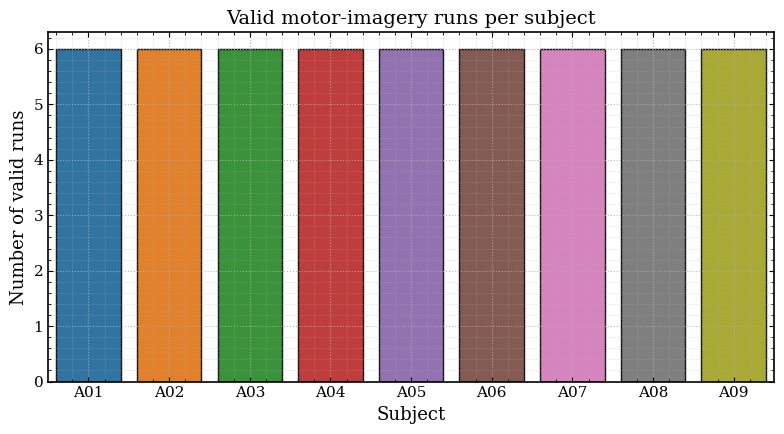

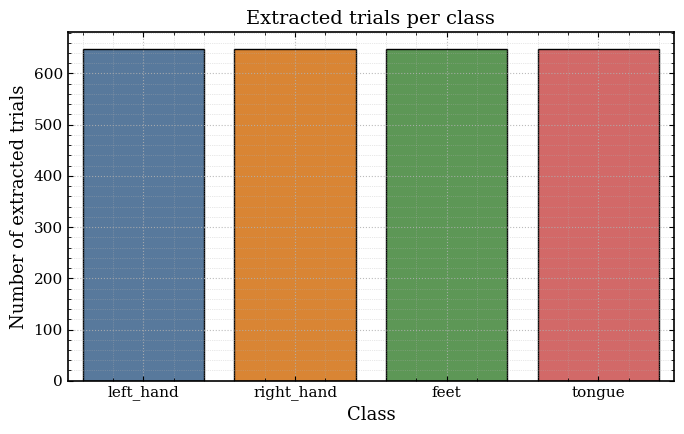

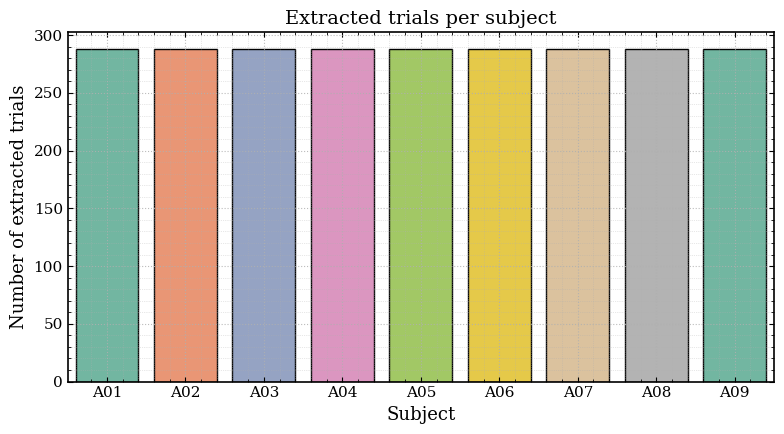

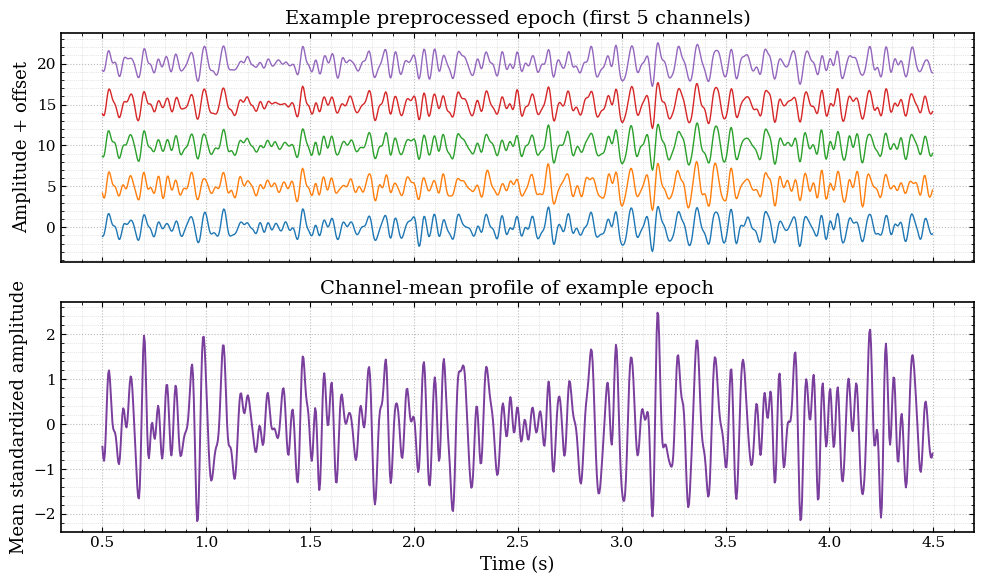

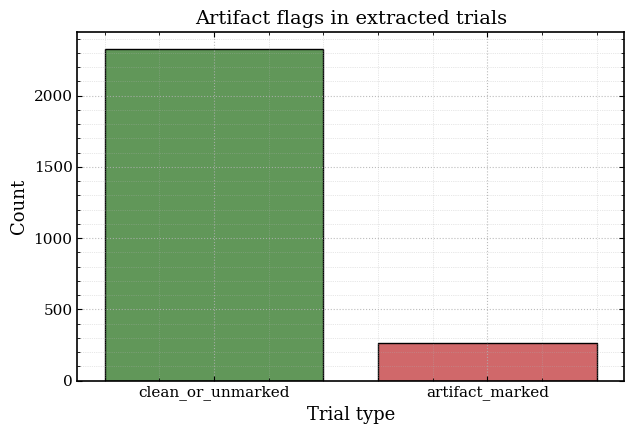


Saved files:
- X.npy
- fig_artifact_flags_extracted.png
- fig_example_preprocessed_epoch.png
- fig_extracted_trials_per_class.png
- fig_extracted_trials_per_subject.png
- fig_valid_runs_per_subject.png
- meta.csv
- run_inventory.csv
- subjects.npy
- y.npy


In [3]:
# ============================================
# EEG Preprocessing + Epoch Extraction — Cell 3
# Validation plots
# ============================================

CLASS_COLORS = {
    "left_hand":  "#4C78A8",
    "right_hand": "#F58518",
    "feet":       "#54A24B",
    "tongue":     "#E45756",
}

# -------------------------------
# Plot 1: Valid MI runs per subject
# -------------------------------
valid_runs_per_subject = (
    run_inventory_df.groupby("subject", as_index=False)["valid_mi_run"]
    .sum()
    .rename(columns={"valid_mi_run": "valid_runs"})
)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=valid_runs_per_subject, x="subject", y="valid_runs",
            palette="tab10", edgecolor="black", ax=ax)
ax.set_title("Valid motor-imagery runs per subject")
ax.set_xlabel("Subject")
ax.set_ylabel("Number of valid runs")
paper_axes(ax)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_valid_runs_per_subject.png", dpi=220, bbox_inches="tight")
plt.show()

# -------------------------------
# Plot 2: Final extracted trials per class
# -------------------------------
class_counts = (
    meta_df.groupby("label_name", as_index=False)
    .size()
    .rename(columns={"size": "count"})
)

ordered = ["left_hand", "right_hand", "feet", "tongue"]
class_counts["label_name"] = pd.Categorical(class_counts["label_name"], categories=ordered, ordered=True)
class_counts = class_counts.sort_values("label_name")

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(
    data=class_counts,
    x="label_name",
    y="count",
    palette=[CLASS_COLORS[c] for c in class_counts["label_name"]],
    edgecolor="black",
    ax=ax
)
ax.set_title("Extracted trials per class")
ax.set_xlabel("Class")
ax.set_ylabel("Number of extracted trials")
paper_axes(ax)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_extracted_trials_per_class.png", dpi=220, bbox_inches="tight")
plt.show()

# -------------------------------
# Plot 3: Extracted trials per subject
# -------------------------------
trial_counts_subj = meta_df.groupby("subject", as_index=False).size().rename(columns={"size": "count"})
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=trial_counts_subj, x="subject", y="count",
            palette="Set2", edgecolor="black", ax=ax)
ax.set_title("Extracted trials per subject")
ax.set_xlabel("Subject")
ax.set_ylabel("Number of extracted trials")
paper_axes(ax)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_extracted_trials_per_subject.png", dpi=220, bbox_inches="tight")
plt.show()

# -------------------------------
# Plot 4: Example epoch before/after standardization check
# -------------------------------
idx = 0
ep = X[idx]   # [T, C]

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
t = np.arange(ep.shape[0]) / FS_EXPECTED + TMIN

for ch in range(min(5, ep.shape[1])):
    axes[0].plot(t, ep[:, ch] + ch * 5, linewidth=1.0, label=f"Ch {ch+1}")
axes[0].set_title("Example preprocessed epoch (first 5 channels)")
axes[0].set_ylabel("Amplitude + offset")
paper_axes(axes[0])

# mean over channels for quick stability view
axes[1].plot(t, ep.mean(axis=1), color="#7A3E9D", linewidth=1.4)
axes[1].set_title("Channel-mean profile of example epoch")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Mean standardized amplitude")
paper_axes(axes[1])

fig.tight_layout()
fig.savefig(OUT_DIR / "fig_example_preprocessed_epoch.png", dpi=220, bbox_inches="tight")
plt.show()

# -------------------------------
# Plot 5: Artifact distribution among kept trials
# -------------------------------
artifact_df = meta_df.groupby("artifact", as_index=False).size().rename(columns={"size": "count"})
artifact_df["artifact_label"] = artifact_df["artifact"].map({0: "clean_or_unmarked", 1: "artifact_marked"}).fillna("other")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.barplot(data=artifact_df, x="artifact_label", y="count",
            palette=["#59A14F", "#E15759"][:len(artifact_df)], edgecolor="black", ax=ax)
ax.set_title("Artifact flags in extracted trials")
ax.set_xlabel("Trial type")
ax.set_ylabel("Count")
paper_axes(ax)
fig.tight_layout()
fig.savefig(OUT_DIR / "fig_artifact_flags_extracted.png", dpi=220, bbox_inches="tight")
plt.show()

print("\nSaved files:")
for f in sorted(OUT_DIR.iterdir()):
    print("-", f.name)